# The delta tilt method

A three-panel illustration of `compute_weighted_tilt` in the modular SEACOFS pipeline, following the supplied schematic. Run all cells on Katana to choose a **random real eddy-day** from the confirmed vertical profiles. Change `SEED` for another example, or set `EDDY_ID` and optionally `REFERENCE_DAY` to choose one yourself. The selected ID and day are printed below. Selection requires seven consecutive usable profiles and a finite, nonzero production tilt; it is for illustration, not an unbiased population sample.

**a)** Seven daily centre profiles. **b)** Reconstruct a representative profile from mean depth increments, then fit a variance-weighted 3-D line. **c)** Compare that fitted tilt with the reference day's horizontal extent.

The fit uses both horizontal coordinates. For display, all panels project onto its horizontal axis, positive from shallow to deep; this preserves the fitted horizontal tilt distance. The arrow points **deep to shallow**, as does `TiltDir`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO = next(p for p in (HERE, *HERE.parents) if (p / 'seacofs_eddy_dataset_modular').is_dir())
sys.path.insert(0, str(REPO / 'seacofs_eddy_dataset_modular' / 'src'))
from seacofs_eddy_dataset.core.tilt import compute_weighted_tilt
OUT = REPO / 'seacofs_eddy_tilt_analysis' / 'delta_tilt_method'

SEED = 200                 # Change this to try another real example
EDDY_ID = None             # None = random eddy; otherwise enter an Eddy ID
REFERENCE_DAY = None       # None = random eligible day within that eddy
PROFILE_PATH = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_profiles_confirmed/profiles.parquet')
NUM = 6                   # Pipeline setting: inclusive k-3 ... k+3 = seven days
DEPTH_INT = 10
MAX_DEPTH = 1000
MIN_DEPTH_RANGE = 200
MIN_POINTS = 5
BEARING_OFFSET = 20.0
EPS = 1e-10
SAVE = False

In [2]:
# Read actual confirmed vertical data; no synthetic fallback.
profiles = pd.read_parquet(PROFILE_PATH, columns=['Eddy', 'Day', 'Depth', 'xc', 'yc'])
if REFERENCE_DAY is not None and EDDY_ID is None:
    raise ValueError('Set EDDY_ID as well when choosing REFERENCE_DAY.')
if EDDY_ID is not None:
    profiles = profiles.loc[profiles.Eddy.eq(EDDY_ID)].copy()
if profiles.empty:
    raise ValueError('No profiles found for the requested selection.')

rng = np.random.default_rng(SEED)
selected = None
# Randomize eddies first, so long tracks do not get more chances merely because
# they contain more days. Screen the seven-day window for a clear schematic.
eddy_ids = rng.permutation(profiles.Eddy.dropna().unique())
for eddy in eddy_ids:
    track = profiles.loc[profiles.Eddy.eq(eddy)].copy()
    view = track.assign(Depth=track.Depth.abs())
    view = view.loc[view.Depth.le(MAX_DEPTH)]
    usable_days = set()
    for day, g in view.groupby('Day'):
        if g.Depth.duplicated().any() or not np.isfinite(g[['Depth', 'xc', 'yc']].to_numpy()).all():
            continue
        levels = np.arange(0, MAX_DEPTH + DEPTH_INT, DEPTH_INT)
        levels = levels[(levels >= g.Depth.min()) & (levels <= g.Depth.max())]
        if len(levels) >= MIN_POINTS + 1 and levels[-2] - levels[0] >= MIN_DEPTH_RANGE:
            usable_days.add(int(day))
    candidates = set(usable_days)
    for offset in range(-NUM // 2, NUM // 2 + 1):
        candidates &= {day - offset for day in usable_days}
    if REFERENCE_DAY is not None:
        candidates &= {int(REFERENCE_DAY)}
    for day in rng.permutation(sorted(candidates)):
        trial = track.loc[track.Day.between(day - NUM // 2, day + NUM // 2)]
        result = compute_weighted_tilt(trial, int(eddy), num=NUM, depth_int=DEPTH_INT,
            max_depth=MAX_DEPTH, min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
            bearing_offset=BEARING_OFFSET)
        result = result.loc[result.Day.eq(day)]
        if len(result) == 1 and np.isfinite(result[['TiltDis', 'TiltDir']].to_numpy()).all() and result.TiltDis.iloc[0] > EPS:
            selected = (int(eddy), int(day), trial.copy())
            break
    if selected is not None:
        break
if selected is None:
    raise ValueError('No eligible seven-day example found. Choose another Eddy/Day or check profile depth coverage.')
EDDY, DAY, profiles = selected
window_days = np.arange(DAY - NUM // 2, DAY + NUM // 2 + 1)
window = profiles.assign(Depth=profiles.Depth.abs())
window = window.loc[window.Depth.le(MAX_DEPTH)].sort_values(['Day', 'Depth'])
print(f'Observed eddy {EDDY}, reference Day {DAY}; {window.Day.nunique()} daily profiles; seed {SEED}')
print(f'To reuse this example: EDDY_ID = {EDDY}; REFERENCE_DAY = {DAY}')
print(window.groupby('Day').agg(levels=('Depth', 'size'), max_depth_m=('Depth', 'max')).to_string())

Observed eddy 2586, reference Day 9360; 7 daily profiles; seed 200
To reuse this example: EDDY_ID = 2586; REFERENCE_DAY = 9360
      levels  max_depth_m
Day                      
9357      22   858.918478
9358      22   858.918478
9359      21   660.806374
9360      22   858.918478
9361      21   660.806374
9362      21   660.806374
9363      21   660.806374


## Reproduce the calculation

1. Interpolate each daily centreline to 10 m depths **within its observed range**.
2. Calculate adjacent-depth increments $\delta x_d(z)$ and $\delta y_d(z)$.
3. Average those increments across the centred seven-calendar-day window, then cumulatively sum them to form $\widetilde{x}(z),\widetilde{y}(z)$. This removes each day's horizontal translation.
4. Weight each depth by $w(z)=1/[\mathrm{Var}(\delta x)+\mathrm{Var}(\delta y)+10^{-10}]$, using sample variances across days. Fit the leading singular vector of the weighted, centred $(\widetilde{x},\widetilde{y},z)$ coordinates.
5. Intersect that line with the shallowest and deepest retained fit depths. Their horizontal separation is `TiltDis`; the deep-to-shallow bearing plus the configured 20° rotation is `TiltDir`.

Implementation details retained here: missing days stay missing; a single available increment cannot supply a sample variance. Cumulative increments are labelled by the **upper** depth of each interval, so an 850 m profile ends at a fit label of 840 m. The fit uses horizontal kilometres and depth metres exactly as the production code does. Display recentering does not alter the fit or distance.

In [3]:
target = np.arange(0, MAX_DEPTH + DEPTH_INT, DEPTH_INT)
index = target[:-1]
dx, dy = {}, {}
for day in window_days:
    g = window.loc[window.Day.eq(day)].sort_values('Depth')
    levels = target[(target >= g.Depth.min()) & (target <= g.Depth.max())]
    if len(g) < 2 or len(levels) < 2:
        dx[day] = pd.Series(np.nan, index=index)
        dy[day] = pd.Series(np.nan, index=index)
        continue
    dx[day] = pd.Series(np.diff(np.interp(levels, g.Depth, g.xc)), index=levels[:-1])
    dy[day] = pd.Series(np.diff(np.interp(levels, g.Depth, g.yc)), index=levels[:-1])
dx, dy = pd.DataFrame(dx), pd.DataFrame(dy)
trace = pd.DataFrame({'x': dx.mean(axis=1).cumsum(), 'y': dy.mean(axis=1).cumsum(),
                      'weight': 1 / (dx.var(axis=1) + dy.var(axis=1) + EPS)})
trace['Depth'] = trace.index
trace = trace.replace([np.inf, -np.inf], np.nan).dropna()
if len(trace) < MIN_POINTS or trace.Depth.max() - trace.Depth.min() < MIN_DEPTH_RANGE:
    raise ValueError('Insufficient common depth support for a valid weighted tilt.')
points = trace[['x', 'y', 'Depth']].to_numpy()
weights = trace.weight.to_numpy() / trace.weight.max()
centre = np.average(points, axis=0, weights=weights)
_, _, vt = np.linalg.svd((points - centre) * np.sqrt(weights[:, None]), full_matrices=False)
v = vt[0]
if abs(v[2]) < EPS:
    raise ValueError('Fit has no usable vertical component.')
top = centre + (points[:, 2].min() - centre[2]) / v[2] * v
bottom = centre + (points[:, 2].max() - centre[2]) / v[2] * v
tilt_distance = np.linalg.norm(bottom[:2] - top[:2])
if tilt_distance < EPS:
    raise ValueError('Zero horizontal tilt: a projected tilt axis is undefined.')
axis = (bottom[:2] - top[:2]) / tilt_distance
tilt_direction = (np.degrees(np.arctan2(*(top[:2] - bottom[:2]))) + BEARING_OFFSET) % 360

# Check the illustrated result against the actual pipeline function.
production = compute_weighted_tilt(profiles, EDDY, num=NUM, depth_int=DEPTH_INT,
    max_depth=MAX_DEPTH, min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
    bearing_offset=BEARING_OFFSET)
match = production.loc[production.Day.eq(DAY)]
if len(match) != 1:
    raise ValueError('Reference day must lie inside the pipeline temporal window.')
np.testing.assert_allclose([tilt_distance, tilt_direction], match[['TiltDis', 'TiltDir']].iloc[0], rtol=1e-9, atol=1e-9)
print(f'Pipeline agreement: TiltDis = {tilt_distance:.2f} km; TiltDir = {tilt_direction:.1f}°')

Pipeline agreement: TiltDis = 15.77 km; TiltDir = 44.9°


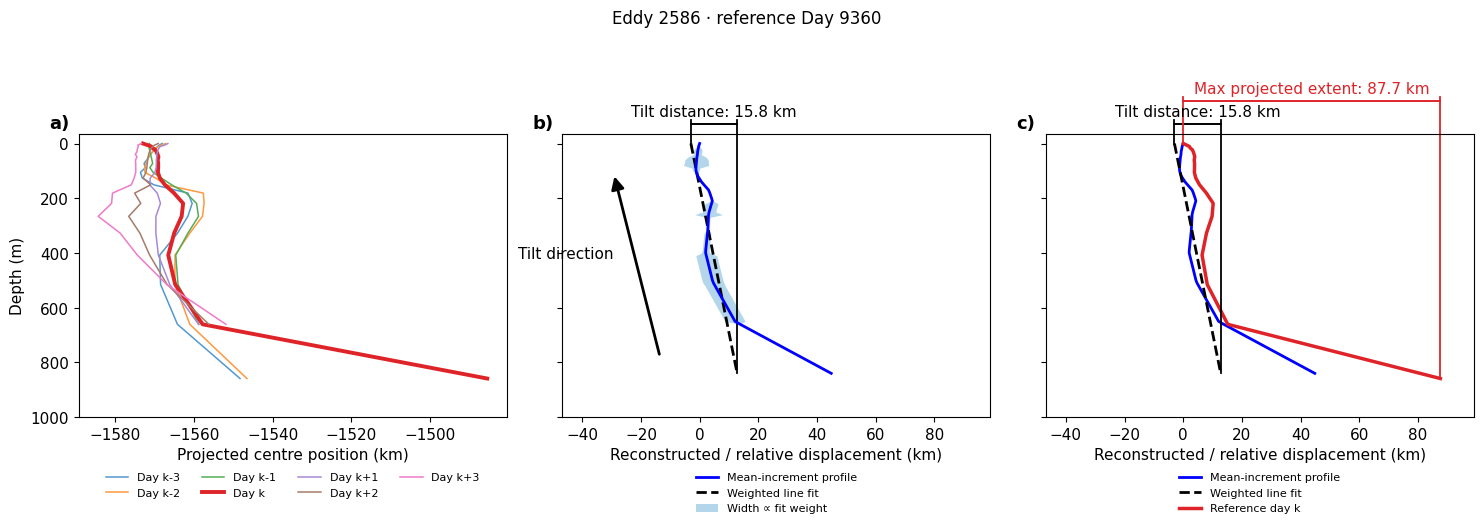

In [4]:
plt.rcParams.update({'font.size': 11, 'axes.spines.top': True, 'axes.spines.right': True})
fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
fig.suptitle(f'Eddy {EDDY} · reference Day {DAY}', y=1.08, fontsize=12)
fig.subplots_adjust(left=0.055, right=0.985, bottom=0.23, top=0.82, wspace=0.13)
colors = ['#5399cf', '#ff993e', '#54ad55', '#df2429', '#a989d4', '#a77b6b', '#ef7bc9']
ref = window.loc[window.Day.eq(DAY)].sort_values('Depth')
ref_xy = ref[['xc', 'yc']].to_numpy()
for day, color in zip(window_days, colors):
    g = window.loc[window.Day.eq(day)]
    if g.empty:
        continue
    offset = int(day - DAY)
    label = 'Day k' if offset == 0 else f'Day k{offset:+d}'
    axs[0].plot(g[['xc', 'yc']].to_numpy() @ axis, g.Depth, color=color,
                lw=2.8 if offset == 0 else 1.1, label=label)
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=4, fontsize=8, frameon=False)
axs[0].set_xlabel('Projected centre position (km)')
axs[0].set_ylabel('Depth (m)')

origin = points[0, :2] @ axis
s = points[:, :2] @ axis - origin
fit_s = np.array([top[:2] @ axis, bottom[:2] @ axis]) - origin
fit_z = np.array([top[2], bottom[2]])
raw_s = (ref_xy - ref_xy[0]) @ axis
for ax in axs[1:]:
    ax.plot(s, points[:, 2], color='blue', lw=2, label='Mean-increment profile')
    ax.plot(fit_s, fit_z, 'k--', lw=2, label='Weighted line fit')
    ax.set_xlabel('Reconstructed / relative displacement (km)')
# Ribbon width encodes the normalized weights, not positional uncertainty.
width = weights * max(tilt_distance * 0.30, 1)
axs[1].fill_betweenx(points[:, 2], s - width, s + width, color='#6baed6', alpha=0.5,
                     linewidth=0, label='Width ∝ fit weight')
axs[1].lines[0].set_zorder(4)
span = max(tilt_distance, np.ptp(raw_s), 1)
arrow_x = fit_s - 0.30 * span
axs[1].annotate('', xy=(arrow_x[0], fit_z[0] + 110),
                xytext=(arrow_x[1], fit_z[1] - 60),
                arrowprops={'arrowstyle': '-|>', 'color': 'black', 'lw': 2, 'mutation_scale': 19})
axs[1].text(arrow_x.mean() - 0.09 * span, fit_z.mean(), 'Tilt direction', ha='right')
axs[2].plot(raw_s, ref.Depth, color='#df2429', lw=2.5, label='Reference day k')

def bracket(ax, left, right, depth, label, color, ends):
    ax.plot([left, right], [depth, depth], color=color, lw=1.4, clip_on=False)
    for x, end in zip([left, right], ends):
        ax.plot([x, x], [depth - 15, end], color=color, lw=1.3, clip_on=False)
    ax.text((left + right) / 2, depth - 18, label, ha='center', va='bottom', color=color)

for ax in axs[1:]:
    bracket(ax, *fit_s, -70, f'Tilt distance: {tilt_distance:.1f} km', 'black', fit_z)
imin, imax = np.argmin(raw_s), np.argmax(raw_s)
bracket(axs[2], raw_s[imin], raw_s[imax], -155,
        f'Max projected extent: {np.ptp(raw_s):.1f} km', '#df2429',
        [ref.Depth.iloc[imin], ref.Depth.iloc[imax]])
lo = min(s.min() - width.max(), raw_s.min(), arrow_x.min()) - 0.20 * span
hi = max(s.max() + width.max(), raw_s.max()) + 0.13 * span
for ax in axs[1:]:
    ax.set_xlim(lo, hi)
for label, ax in zip(['a)', 'b)', 'c)'], axs):
    ax.set_ylim(MAX_DEPTH, -35)
    ax.text(-0.07, 1.02, label, transform=ax.transAxes, fontweight='bold', fontsize=13)
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=8, frameon=False)
axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=8, frameon=False)
if SAVE:
    tag = f'eddy_{EDDY}_day_{DAY}'
    for ext in ['png', 'pdf']:
        fig.savefig(OUT / f'delta_tilt_schematic_{tag}.{ext}', dpi=220, bbox_inches='tight')
plt.show()

**Reading panel c.** The red bracket is the reference day's maximum minus minimum position **projected onto the fitted tilt axis**. It illustrates the older schematic's “max displacement” comparison, but is not necessarily the maximum pairwise 2-D displacement or maximum displacement from the surface. The black bracket is the horizontal endpoint separation of the weighted fit to the reconstructed, smoothed profile. They need not agree: the reference profile can curve, and the delta method averages increments across days and downweights inconsistent increments.

The blue ribbon in b encodes relative fit weights; it is **not a confidence interval**. Missing days and differing profile depths can change the number of contributions with depth. This notebook illustrates the existing implementation without modifying the production method.